In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

Training AND...
AND Predictions: [0.0, 0.0, 0.0, 1.0]


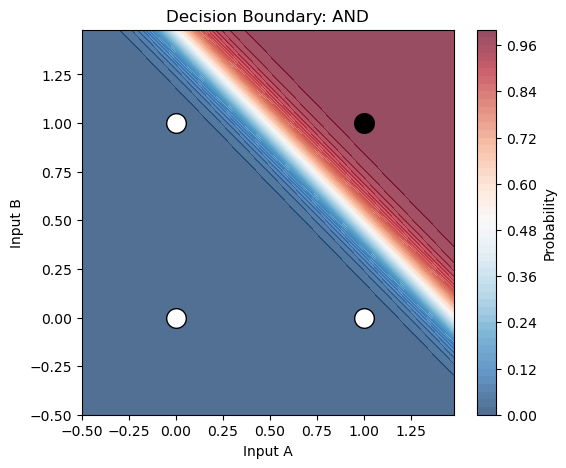

Training OR...
OR Predictions: [0.0, 1.0, 1.0, 1.0]


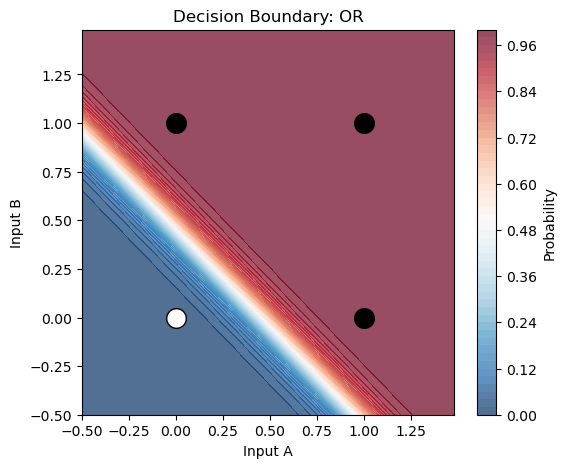

Training NAND...
NAND Predictions: [1.0, 1.0, 1.0, 0.0]


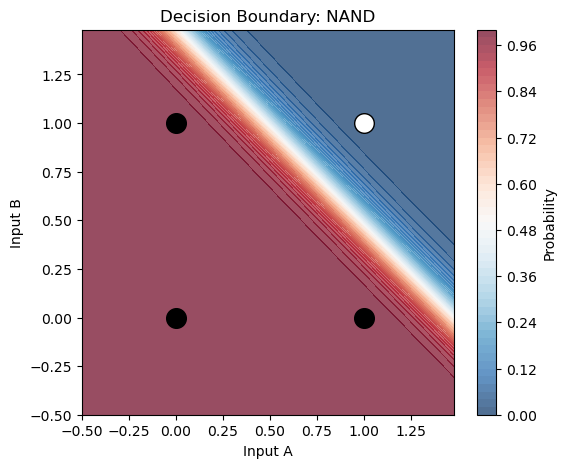

Training NOR...
NOR Predictions: [1.0, 0.0, 0.0, 0.0]


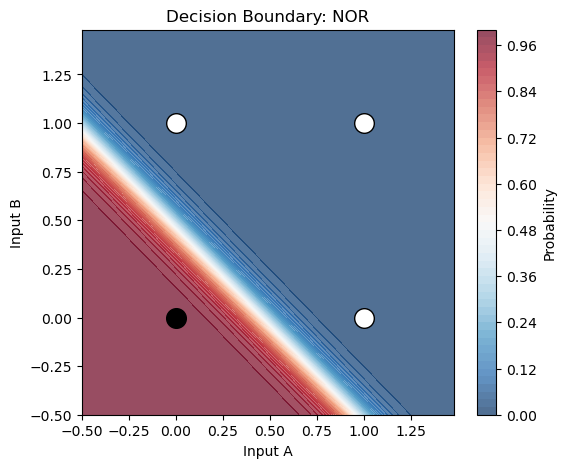

Training XOR...
XOR Predictions: [0.0, 1.0, 1.0, 0.0]


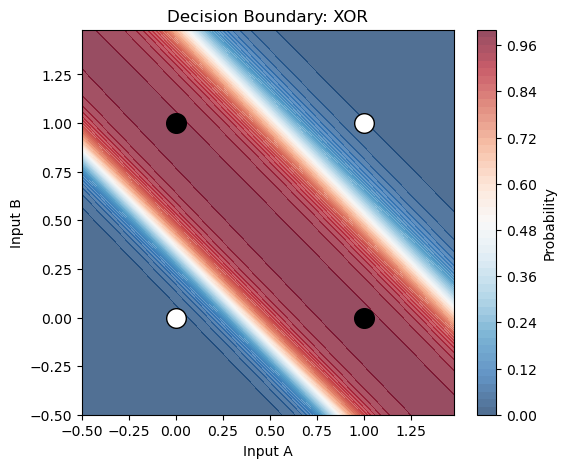

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

X = torch.tensor([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=torch.float32)

gates = {
    "AND":  torch.tensor([[0], [0], [0], [1]], dtype=torch.float32),
    "OR":   torch.tensor([[0], [1], [1], [1]], dtype=torch.float32),
    "NAND": torch.tensor([[1], [1], [1], [0]], dtype=torch.float32),
    "NOR":  torch.tensor([[1], [0], [0], [0]], dtype=torch.float32),
    "XOR":  torch.tensor([[0], [1], [1], [0]], dtype=torch.float32),
}

class LogicGateNet(nn.Module):
    def __init__(self):
        super(LogicGateNet, self).__init__()
        self.hidden = nn.Linear(2, 4)
        self.output = nn.Linear(4, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

def plot_decision_boundary(gate_name, model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    grid_tensor = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
    
    with torch.no_grad():
        probs = model(grid_tensor).reshape(xx.shape)
    
    plt.figure(figsize=(6, 5))
    plt.contourf(xx, yy, probs, levels=50, cmap='RdBu_r', alpha=0.7)
    plt.colorbar(label='Probability')
    
    y_flat = y.flatten().numpy()
    for i in range(len(X)):
        color = 'white' if y_flat[i] == 0 else 'black'
        plt.scatter(X[i,0], X[i,1], color=color, edgecolors='k', s=200)

    plt.title(f"Decision Boundary: {gate_name}")
    plt.xlabel("Input A")
    plt.ylabel("Input B")
    plt.show()
    plt.close()

def train_and_visualize():
    for gate_name, target in gates.items():
        model = LogicGateNet()
        criterion = nn.BCELoss()
        optimizer = optim.SGD(model.parameters(), lr=0.5)

        print(f"Training {gate_name}...")
        
        for epoch in range(2001):
            optimizer.zero_grad()
            outputs = model(X)
            loss = criterion(outputs, target)
            loss.backward()
            optimizer.step()
        
        with torch.no_grad():
            predictions = model(X).round()
            print(f"{gate_name} Predictions: {predictions.flatten().tolist()}")
        
        plot_decision_boundary(gate_name, model, X, target)

if __name__ == "__main__":
    train_and_visualize()